In [1]:
library(Seurat)
library(SeuratDisk)
library(ggplot2)

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Attaching SeuratObject

Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat



In [2]:
obj <- LoadH5Seurat("/opt/data/private/obj_all_covid.label_update.h5seurat")

Validating h5Seurat file



Initializing adt with data

Adding counts for adt

Adding miscellaneous information for adt

Initializing rna with data

Adding counts for rna

Adding miscellaneous information for rna

Initializing z with data

Adding counts for z

Adding scale.data for z

Adding variable feature information for z

Adding miscellaneous information for z

Adding reduction c

Adding cell embeddings for c

Adding miscellaneous information for c

Adding reduction c.umap

Adding cell embeddings for c.umap

Adding miscellaneous information for c.umap

Adding graph z_nn

Adding graph z_snn

Adding command information

Adding cell-level metadata

Adding miscellaneous information

Adding tool-specific results



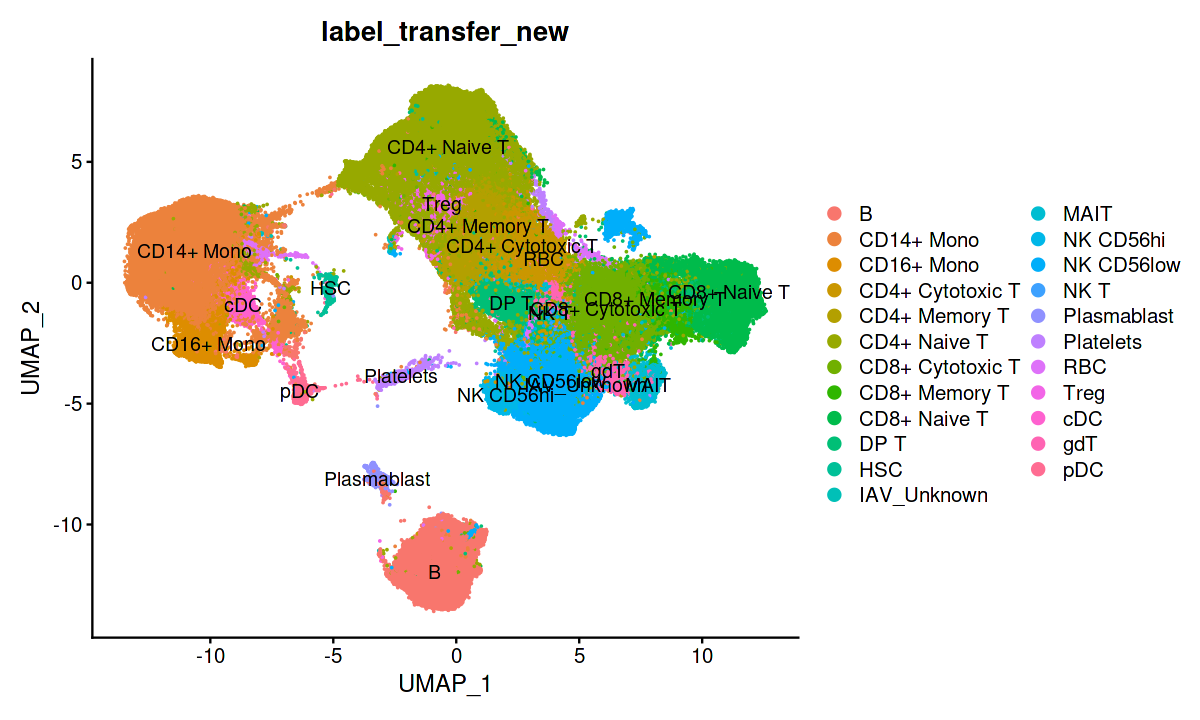

In [3]:
options(repr.plot.width = 10, repr.plot.height = 6)
DimPlot(obj,group.by = "label_transfer_new",raster=FALSE,label = TRUE)

In [4]:
Idents(obj) <- "batch"
table(Idents(obj))


                lll_ctrl                 lll_stim                 dig_ctrl 
                    7361                     5897                    10190 
                dig_stim                       w1                       w3 
                    9527                     7325                     6587 
                      w4                       w5                       w6 
                    6897                     6910                     7137 
            tea_multi_w1             tea_multi_w2 10x_multiome_chrom_x_10k 
                    6096                     7284                     9868 
10x_multiome_chrom_c_10k    10x_multiome_arc2_10k     10x_multiome_arc2_3k 
                    9582                    11116                     2566 
               asap_ctrl                asap_stim                cite_ctrl 
                    4255                     5241                     5086 
               cite_stim                     p1_0                     p2_0 
           


    HC  COVID    IAV 
252789  97938  15693 

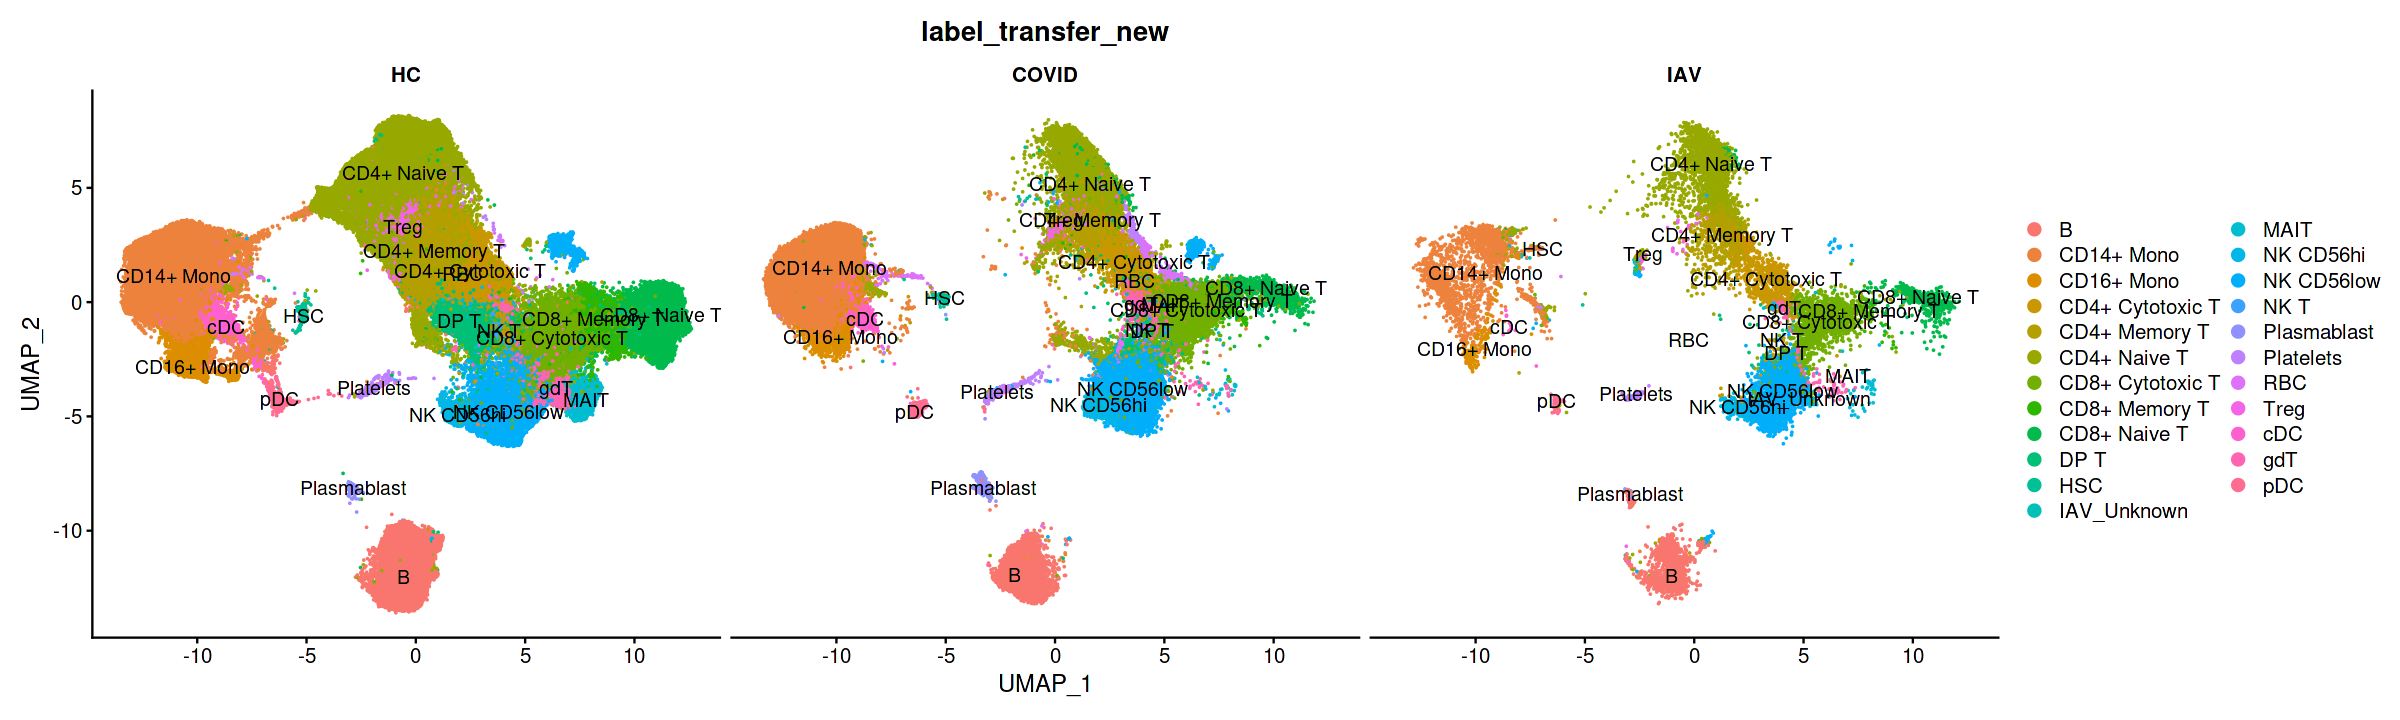

In [5]:
ids <- c("HC","HC","HC","HC","HC","HC","HC",
         "HC","HC","HC","HC","HC","HC","HC",
         "HC","HC","HC","HC","HC","HC","HC",
         "HC","HC","HC","HC","HC","HC","HC",
         "HC","HC","HC","HC","HC","HC",
         "COVID","COVID","COVID","COVID","COVID",
         "COVID","COVID","COVID","COVID","COVID",
         "IAV","IAV","IAV","IAV",
         "IAV","IAV","IAV")
names(ids) <- levels(obj)
obj <- RenameIdents(obj, ids)
table(Idents(obj))
obj[["disease"]] <- Idents(object = obj)
Idents(obj) <- "label_transfer_new"

options(repr.plot.width = 20, repr.plot.height = 6)
DimPlot(obj,group.by="label_transfer_new",raster=FALSE,split.by="disease",label = TRUE)

In [6]:
DefaultAssay(object = obj) <- "rna"
obj <- NormalizeData(obj)
obj <- FindNeighbors(obj, reduction = "c", graph.name = c("nn","snn"), dims = 1:30)
obj <- FindClusters(obj, graph.name = "snn", resolution = 2)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 366420
Number of edges: 8730589

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8664
Number of communities: 89
Elapsed time: 180 seconds


19 singletons identified. 70 final clusters.



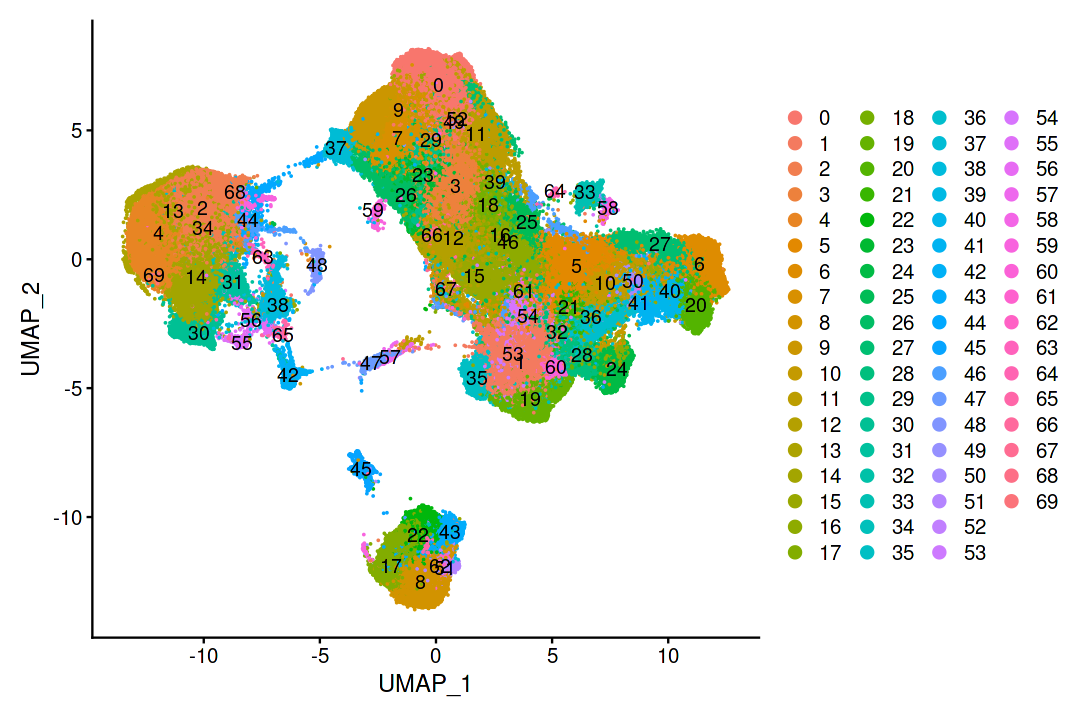

In [7]:
options(repr.plot.width = 9, repr.plot.height = 6)
DimPlot(obj,label = TRUE,raster=FALSE)

In [8]:
obj[["seurat_clusters"]] <- Idents(object = obj)

In [9]:
cluster59 <- WhichCells(obj, ident = 59)

In [10]:
celltype <- readRDS("/opt/data/private/IAV_label.update.rds")

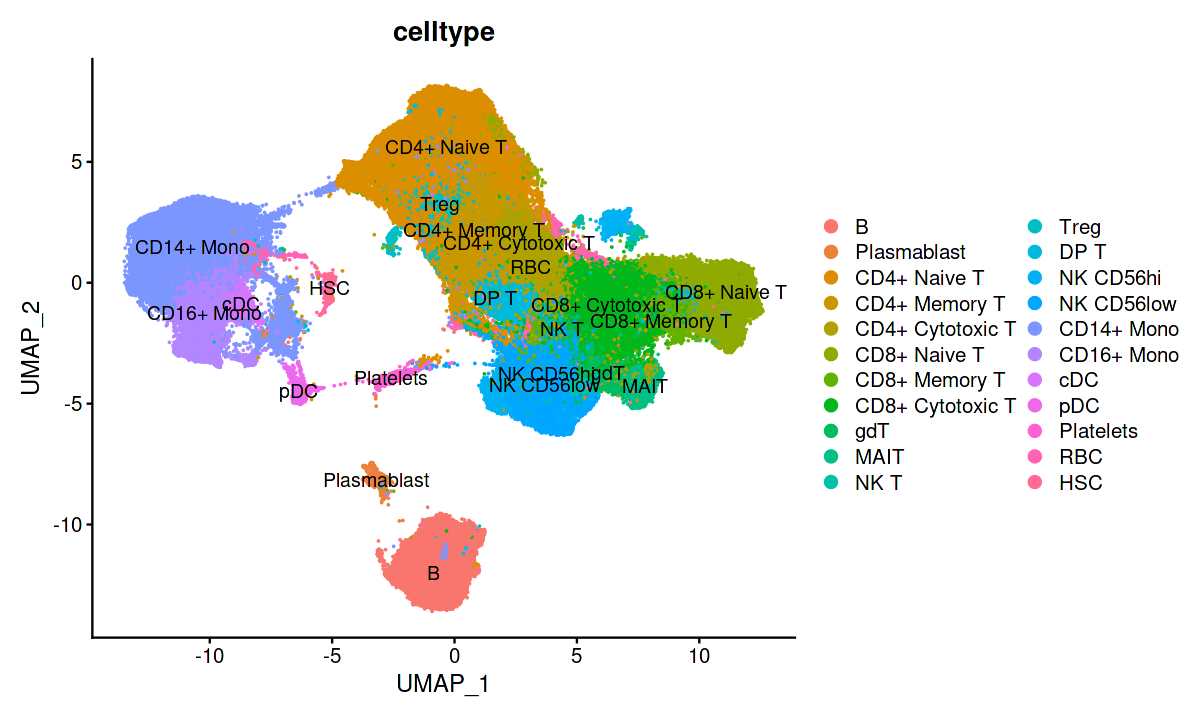

In [11]:
obj@meta.data$celltype <- celltype

options(repr.plot.width = 10, repr.plot.height = 6)
DimPlot(obj,label = TRUE, group.by = "celltype",raster=FALSE)

In [12]:
Idents(obj) <- "celltype"
table(Idents(obj))


               B      Plasmablast     CD4+ Naive T    CD4+ Memory T 
           29230             1342            76247            30355 
CD4+ Cytotoxic T     CD8+ Naive T    CD8+ Memory T CD8+ Cytotoxic T 
           21756            25947             3523            37510 
             gdT             MAIT             NK T             Treg 
            3700             4854             2555             6032 
            DP T        NK CD56hi       NK CD56low       CD14+ Mono 
            8859             5726            30097            56960 
      CD16+ Mono              cDC              pDC        Platelets 
           13076             3156             1741             1571 
             RBC              HSC 
            1213              970 

In [13]:
Idents(obj, cells = cluster59) <- "Unknown"

In [ ]:
table(Idents(obj))


         Unknown                B      Plasmablast     CD4+ Naive T 
             486            29183             1342            76247 
   CD4+ Memory T CD4+ Cytotoxic T     CD8+ Naive T    CD8+ Memory T 
           30355            21756            25947             3523 
CD8+ Cytotoxic T              gdT             MAIT             NK T 
           37510             3700             4854             2555 
            Treg             DP T        NK CD56hi       NK CD56low 
            5747             8859             5726            30097 
      CD14+ Mono       CD16+ Mono              cDC              pDC 
           56806            13076             3156             1741 
       Platelets              RBC              HSC 
            1571             1213              970 

In [15]:
obj[["celltype"]] <- Idents(object = obj)

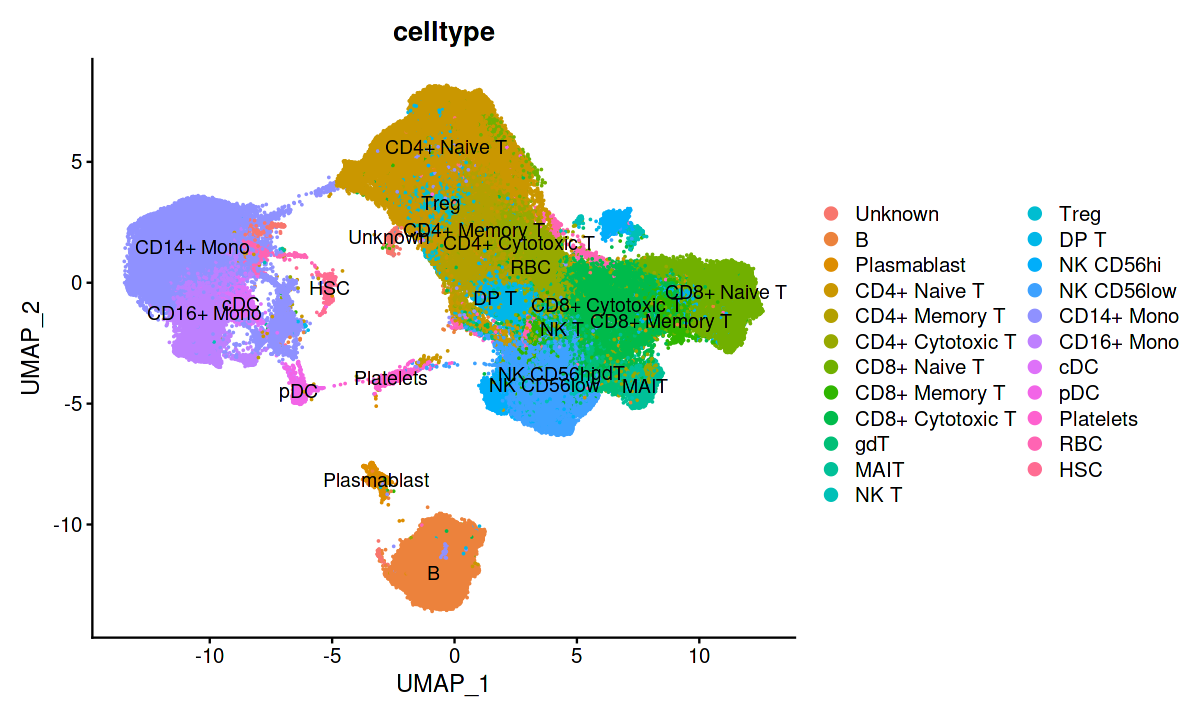

In [16]:
DimPlot(obj,label = TRUE, group.by = "celltype",raster=FALSE)

In [17]:
Idents(obj) <- "disease"
IAV <- subset(obj,idents = c('IAV'))
Idents(IAV) <- "celltype"

In [18]:
Unknown_marker_IAV <- FindMarkers(IAV, ident.1 = "Unknown", only.pos = TRUE)

In [19]:
write.csv(Unknown_marker_IAV,"/opt/data/private/Update/Unknown_marker_IAV.csv")

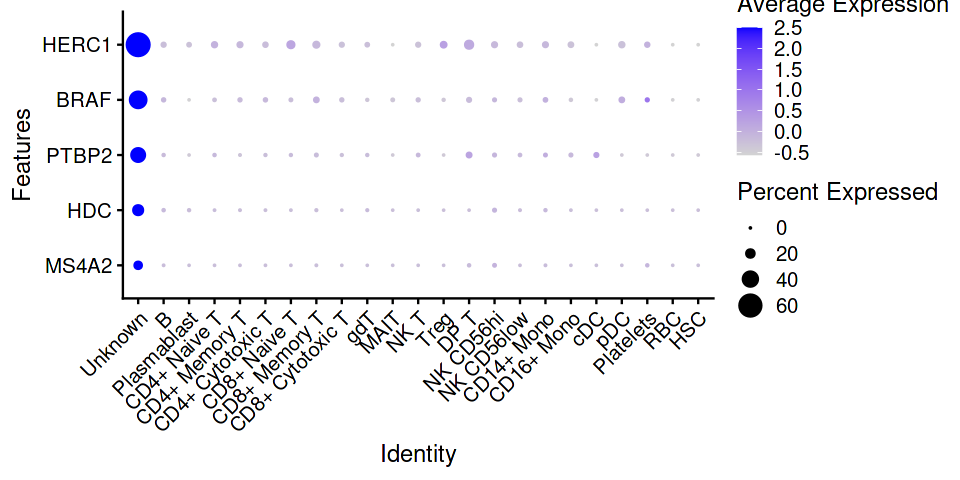

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 4)
DotPlot(IAV,features = c("MS4A2","HDC","PTBP2","BRAF","HERC1"))+
 coord_flip()+
 theme(axis.text.x = element_text(angle = 45, hjust = 1))

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
"Removed 18194 rows containing non-finite values (`stat_ydensity()`)."
Warning message:
"Groups with fewer than two data points have been dropped."
Warning message:
"Groups with fewer than two data points have been dropped."


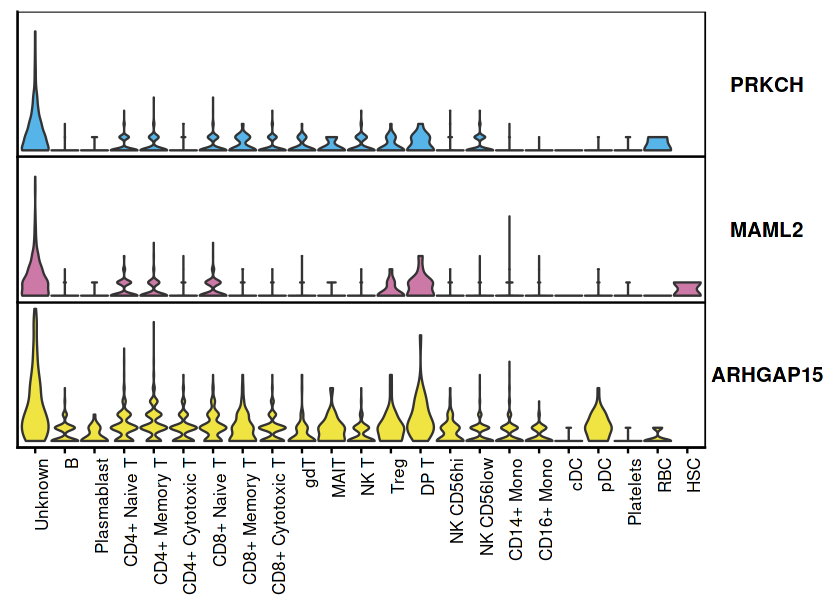

In [ ]:
features <- c("PRKCH", "MAML2","ARHGAP15")
colors <- c("#56B4E9","#CC79A7","#F0E442")

options(repr.plot.width = 7, repr.plot.height = 5)
VlnPlot(IAV, features, slot = "count",stack = TRUE,flip = TRUE,pt.size=0,
        cols = colors, add.noise = TRUE, adjust = 1.2)+
  scale_y_continuous(limits = c(0, 10))+
  theme(axis.text.y = element_blank(), 
        axis.ticks.y = element_blank(),
        axis.title = element_blank(),
        axis.text.x = element_text(colour = 'black',size = 10,angle = 90),
        legend.position = 'none')

In [22]:
Idents(obj) <- "celltype"
Idents(obj, cells = cluster59) <- "T_HERC1"

In [23]:
obj[["celltype"]] <- Idents(object = obj)

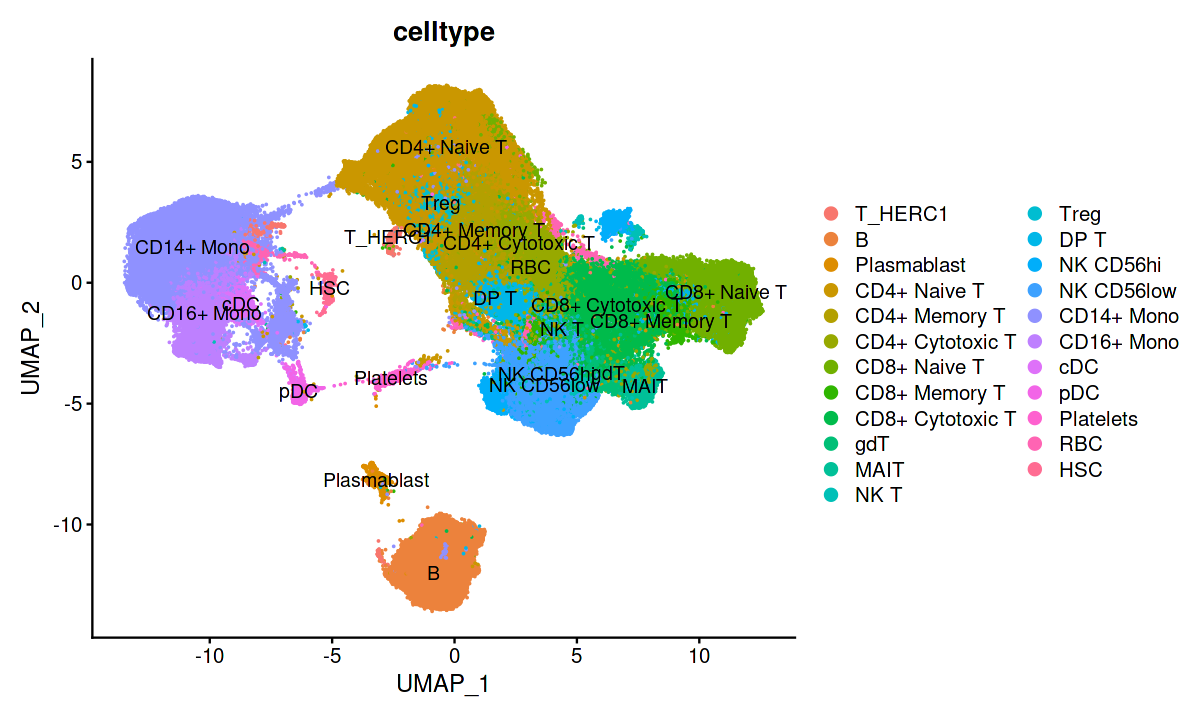

In [24]:
options(repr.plot.width = 10, repr.plot.height = 6)
DimPlot(obj,label = TRUE, group.by = "celltype",raster=FALSE)

In [25]:
Idents(obj) <- "disease"
IAV <- subset(obj,idents = c('IAV'))
Idents(IAV) <- "celltype"
table(Idents(IAV))


         T_HERC1                B      Plasmablast     CD4+ Naive T 
             468             1723               49             2238 
   CD4+ Memory T CD4+ Cytotoxic T     CD8+ Naive T    CD8+ Memory T 
             796             1202              864              132 
CD8+ Cytotoxic T              gdT             MAIT             NK T 
            1523              149               28              552 
            Treg             DP T        NK CD56hi       NK CD56low 
              50               42              168             3056 
      CD14+ Mono       CD16+ Mono              cDC              pDC 
            2059              429               14               55 
       Platelets              RBC              HSC 
              88                6                2 

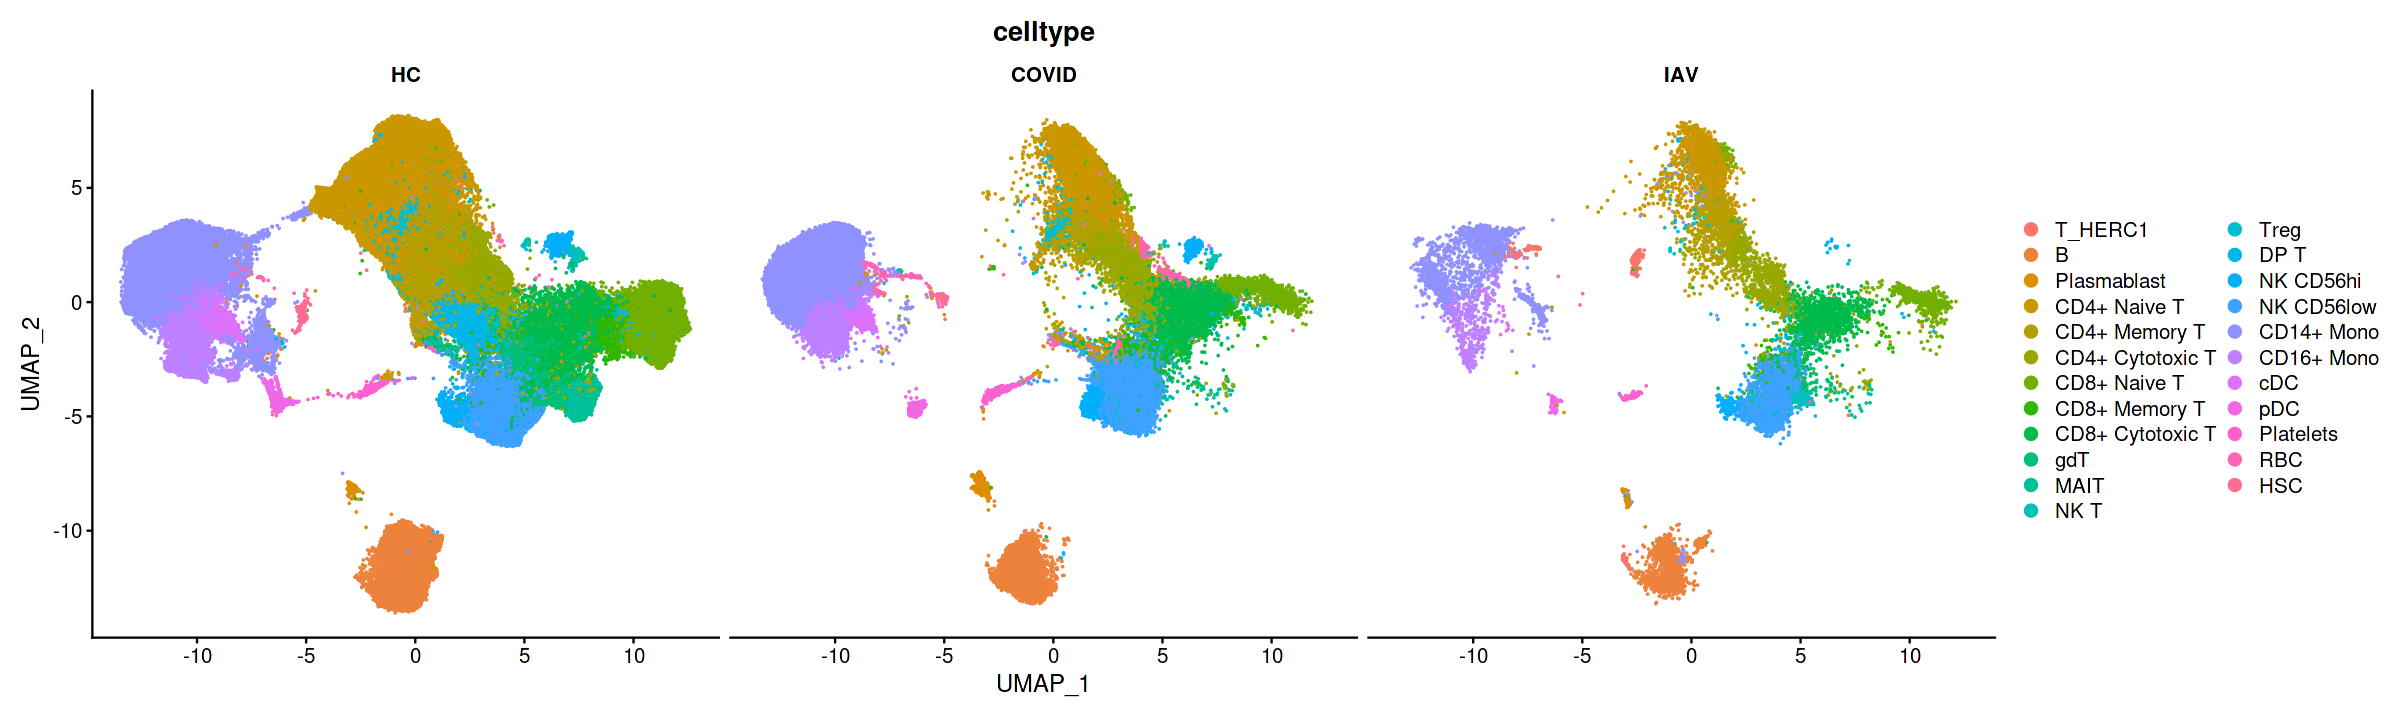

In [26]:
options(repr.plot.width = 20, repr.plot.height = 6)
DimPlot(obj,group.by="celltype",raster=FALSE,split.by="disease")

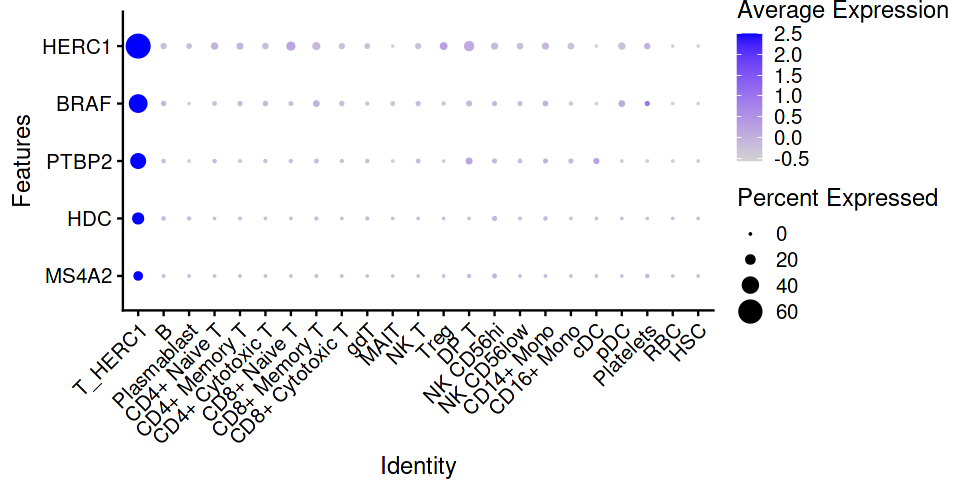

In [27]:
options(repr.plot.width = 8, repr.plot.height = 4.1)
p1 <- DotPlot(IAV,features = c("MS4A2","HDC","PTBP2","BRAF","HERC1"))+
 coord_flip()+
 theme(axis.text.x = element_text(angle = 45, hjust = 1))
p1

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
"Removed 18194 rows containing non-finite values (`stat_ydensity()`)."
Warning message:
"Groups with fewer than two data points have been dropped."
Warning message:
"Groups with fewer than two data points have been dropped."


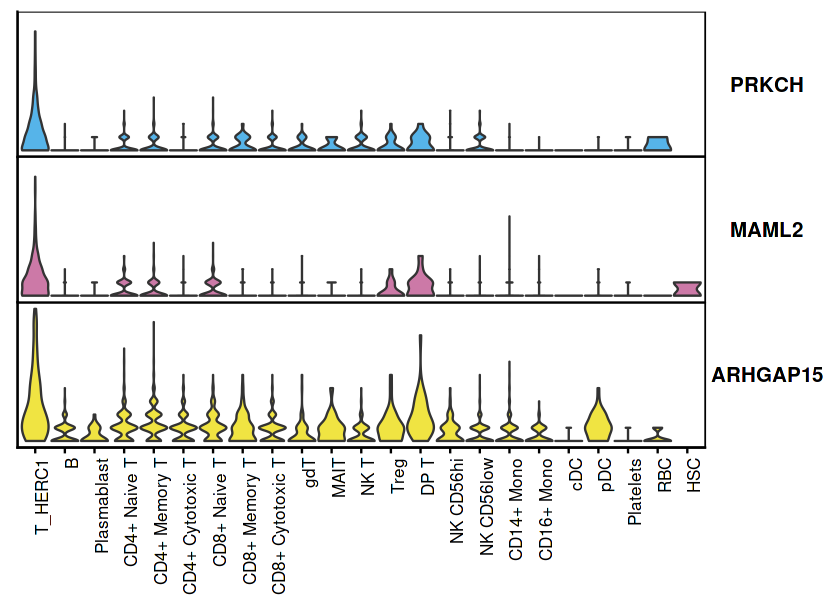

In [31]:
features <- c("PRKCH", "MAML2","ARHGAP15")
colors <- c("#56B4E9","#CC79A7","#F0E442")

options(repr.plot.width = 7, repr.plot.height = 5)
p3 <- VlnPlot(IAV, features, slot = "count",stack = TRUE,flip = TRUE,pt.size=0,
        cols = colors, add.noise = TRUE, adjust = 1.2)+
  scale_y_continuous(limits = c(0, 10))+
  theme(axis.text.y = element_blank(), 
        axis.ticks.y = element_blank(),
        axis.title = element_blank(),
        axis.text.x = element_text(colour = 'black',size = 10,angle = 90),
        legend.position = 'none')
p3

In [120]:
saveRDS(obj,"/opt/data/private/Update/obj_IAV.rds")

In [33]:
IAV_celltype <- obj@meta.data$celltype
saveRDS(IAV_celltype,"/opt/data/private/Update/IAV_celltype.rds")

In [34]:
raw <- readRDS("/opt/data/private/iScience_raw_data_V4.rds")

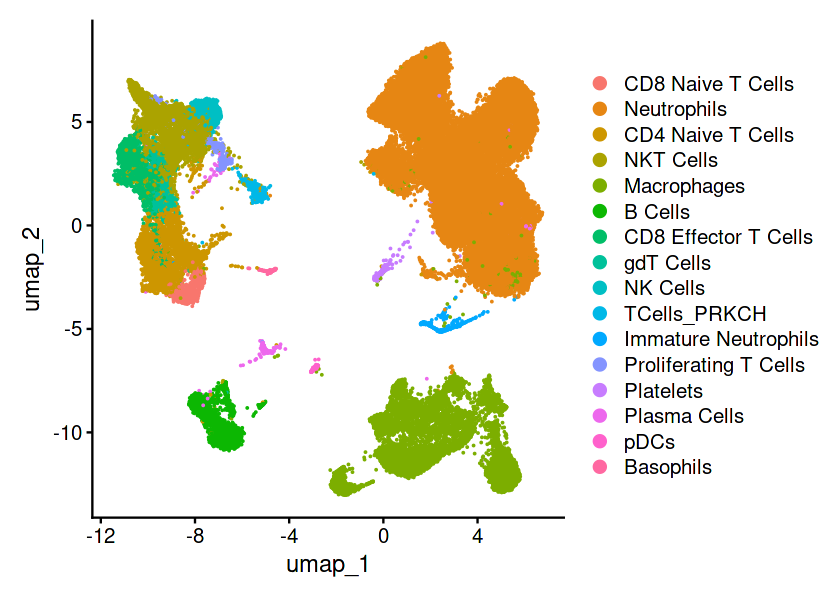

In [36]:
options(repr.plot.width = 7, repr.plot.height = 5)
p4 <- DimPlot(raw, raster = FALSE)
p4

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
"Removed 73993 rows containing non-finite values (`stat_ydensity()`)."


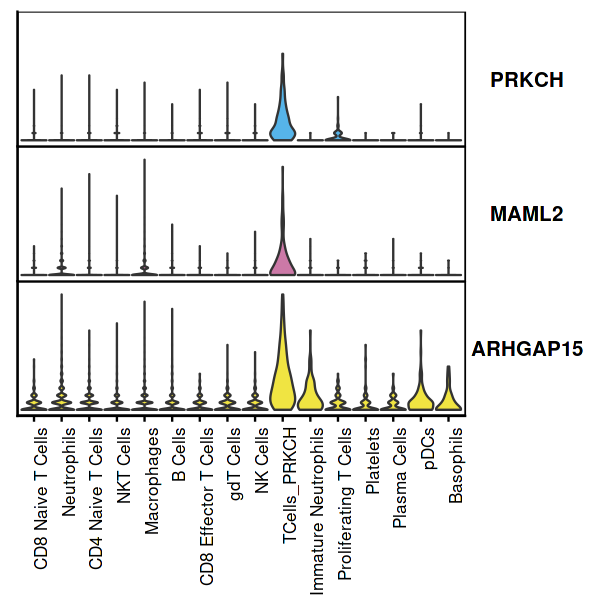

In [38]:
features <- c("PRKCH", "MAML2","ARHGAP15")
colors <- c("#56B4E9","#CC79A7","#F0E442")

options(repr.plot.width = 5, repr.plot.height = 5)
p5 <- VlnPlot(raw, features, stack = TRUE,flip = TRUE,pt.size=0,
        cols = colors, add.noise = TRUE,slot = "count")+
  scale_y_continuous(limits = c(0, 17))+
  theme(axis.text.y = element_blank(), 
        axis.ticks.y = element_blank(),
        axis.title = element_blank(),
        axis.text.x = element_text(colour = 'black',size = 10,angle = 90),
        legend.position = 'none')
p5